# Домашнее задание №5: Анализ выбросов и кодирование признаков



## 1. Подготовка данных (из ДЗ 4)

Загрузим датасет и заполним пропуски методами, обоснованными в предыдущей работе.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка
df = pd.read_csv('loan_prediction_dataset.csv')

# Заполнение пропусков (как в ДЗ 4)
cat_cols = df.select_dtypes(exclude=[np.number]).columns
num_cols = df.select_dtypes(include=[np.number]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"Пропусков после обработки: {df.isnull().sum().sum()}")
df.head()

Пропусков после обработки: 0


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 2. Поиск выбросов

Найдем выбросы для `ApplicantIncome` и `LoanAmount` двумя способами: IQR и метод стандартного отклонения.

In [ ]:
def get_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)].index.tolist()

def get_outliers_std(data, column):
    mean = data[column].mean()
    std = data[column].std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)].index.tolist()

features = ['ApplicantIncome', 'LoanAmount']
outliers_results = {}

for feature in features:
    iqr_outliers = get_outliers_iqr(df, feature)
    std_outliers = get_outliers_std(df, feature)
    outliers_results[feature] = {'IQR': iqr_outliers, 'STD': std_outliers}

    print(f"--- {feature} ---")
    print(f"Выбросов по IQR: {len(iqr_outliers)}")
    print(f"Выбросов по STD: {len(std_outliers)}")

--- ApplicantIncome ---
Выбросов по IQR: 50
Выбросов по STD: 8
--- LoanAmount ---
Выбросов по IQR: 41
Выбросов по STD: 15


## 3. Сравнение и интерпретация методов

Проанализируем пересечение списков выбросов.

In [ ]:
for feature in features:
    iqr_set = set(outliers_results[feature]['IQR'])
    std_set = set(outliers_results[feature]['STD'])

    intersection = iqr_set.intersection(std_set)
    only_iqr = iqr_set - std_set

    print(f"--- {feature} ---")
    print(f"Пересечение (оба метода): {len(intersection)}")
    print(f"Только в IQR: {len(only_iqr)}")
    print(f"Только в STD: {len(std_set - iqr_set)}")

--- ApplicantIncome ---
Пересечение (оба метода): 8
Только в IQR: 42
Только в STD: 0
--- LoanAmount ---
Пересечение (оба метода): 15
Только в IQR: 26
Только в STD: 0


### Причины различий:
1. **IQR-правило** более чувствительно к выбросам, так как оно опирается на квантили и не зависит от формы распределения. Оно часто находит больше выбросов в асимметричных данных.
2. **Метод STD** предполагает нормальное распределение (правило 3-х сигм). Если данные имеют "тяжелые хвосты" или сильную асимметрию (как доходы), метод STD может пропускать экстремальные значения, которые IQR считает выбросами.
3. В нашем случае IQR находит значительно больше выбросов, что характерно для финансовых данных с правосторонней асимметрией.

## 4. Визуализация выбросов

Используем Boxplot и гистограммы для подтверждения наличия экстремальных значений.

/tmp/ipykernel_3843/1014524939.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], ax=axes[i, 0], palette='Set2')
/tmp/ipykernel_3843/1014524939.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], ax=axes[i, 0], palette='Set2')


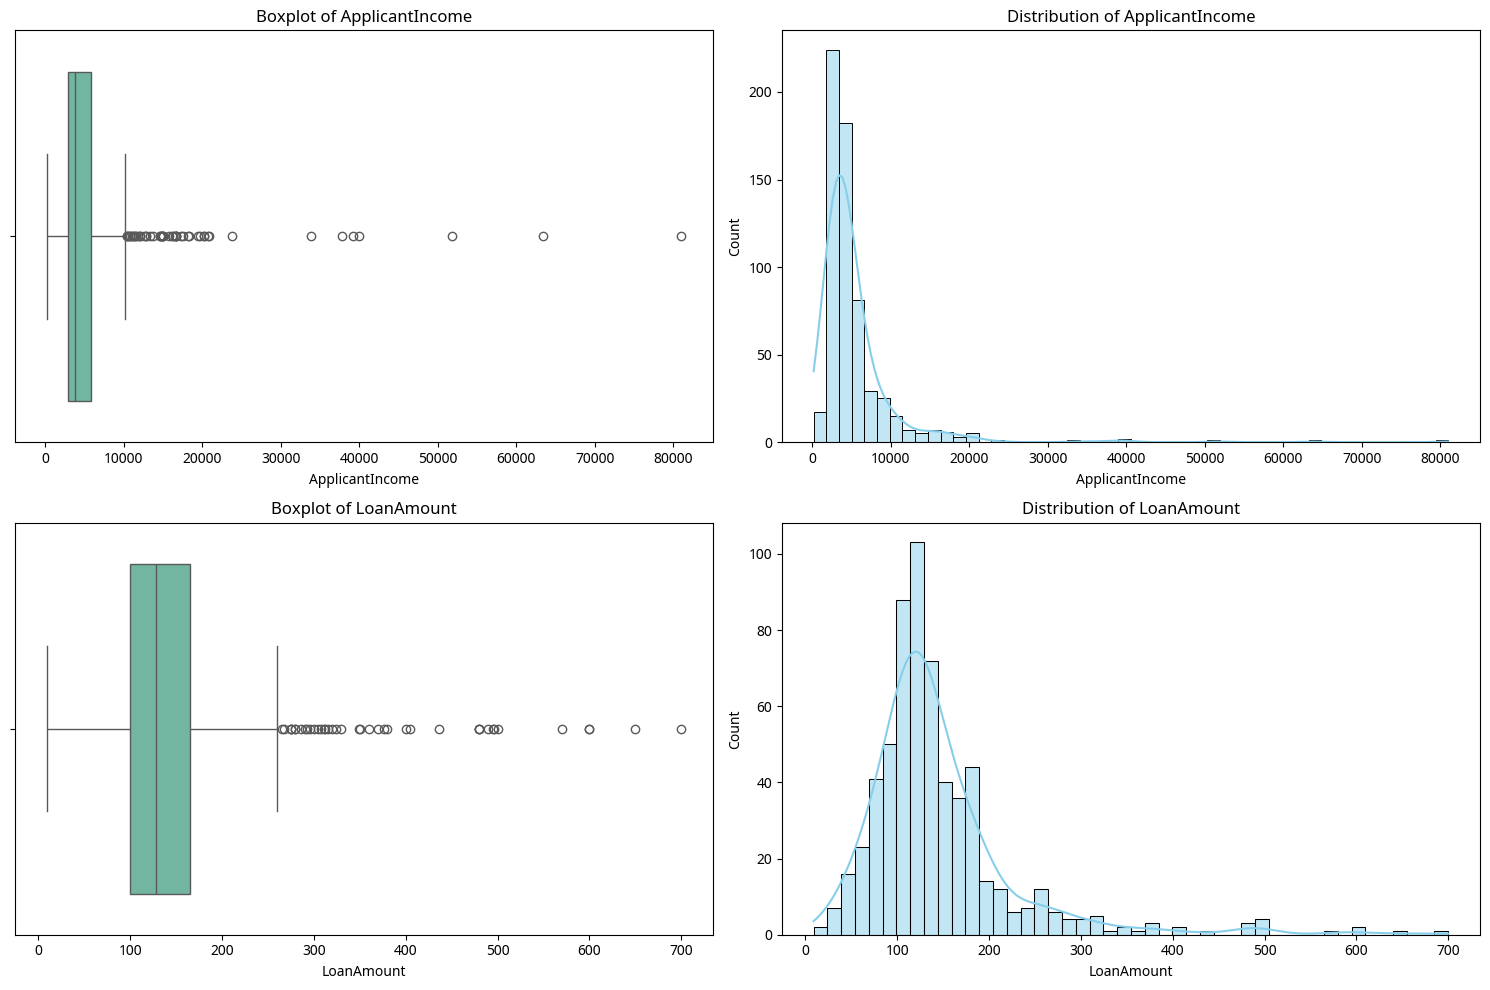

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, feature in enumerate(features):
    sns.boxplot(x=df[feature], ax=axes[i, 0], palette='Set2')
    axes[i, 0].set_title(f'Boxplot of {feature}')

    sns.histplot(df[feature], kde=True, ax=axes[i, 1], color='skyblue')
    axes[i, 1].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

## 5. Решение по обработке выбросов

**Решение:** Оставить выбросы (с возможной последующей логарифмизацией).

**Обоснование:**
1. **Природа данных:** В кредитном скоринге высокие доходы (`ApplicantIncome`) и большие суммы кредитов (`LoanAmount`) — это реальные рыночные ситуации, а не ошибки ввода. Удаление этих данных приведет к потере информации о наиболее состоятельных клиентах.
2. **Размер выборки:** Удаление всех выбросов по IQR (около 50+ строк) существенно сократит и без того небольшой датасет.
3. **Модели:** Для моделей на основе деревьев решений (Random Forest, XGBoost) выбросы не являются критичной проблемой. Для линейных моделей лучше применить логарифмическое преобразование, чем удаление.

## 6. Кодирование категориальных переменных

### Варианты и обоснование:
1. **Binary Encoding (0/1):** Для бинарных признаков (`Gender`, `Married`, `Education`, `Self_Employed`, `Loan_Status`). Это наиболее эффективно и не увеличивает размерность.
2. **One-Hot Encoding:** Для признака `Property_Area` (3 категории: Urban, Semiurban, Rural), так как между ними нет явного порядка.
3. **Ordinal Encoding:** Для `Dependents` (0, 1, 2, 3+), так как здесь есть естественный порядок возрастания.

In [ ]:
# Копия для трансформации
df_encoded = df.copy()

# 1. Binary Encoding
binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
for col in binary_cols:
    # Используем map для контроля значений
    if col == 'Education':
        df_encoded[col] = df_encoded[col].map({'Graduate': 1, 'Not Graduate': 0})
    elif col == 'Loan_Status':
        df_encoded[col] = df_encoded[col].map({'Y': 1, 'N': 0})
    else:
        # Для Gender, Married, Self_Employed берем первый элемент моды как 1
        unique_vals = df_encoded[col].unique()
        df_encoded[col] = df_encoded[col].map({unique_vals[0]: 1, unique_vals[1]: 0})

# 2. Ordinal Encoding для Dependents
df_encoded['Dependents'] = df_encoded['Dependents'].replace('3+', 3).astype(int)

# 3. One-Hot Encoding для Property_Area
df_encoded = pd.get_dummies(df_encoded, columns=['Property_Area'], prefix='Area')

# Удаление Loan_ID (не несет полезной информации для модели)
df_encoded.drop('Loan_ID', axis=1, inplace=True)

print("Кодирование завершено.")
df_encoded.head()

Кодирование завершено.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Area_Rural,Area_Semiurban,Area_Urban
0,1,1,0,1,1,5849,0.0,128.0,360.0,1.0,1,False,False,True
1,1,0,1,1,1,4583,1508.0,128.0,360.0,1.0,0,True,False,False
2,1,0,0,1,0,3000,0.0,66.0,360.0,1.0,1,False,False,True
3,1,0,0,0,1,2583,2358.0,120.0,360.0,1.0,1,False,False,True
4,1,1,0,1,1,6000,0.0,141.0,360.0,1.0,1,False,False,True


## 7. Проверка результата

Проверим типы данных, размерность и отсутствие ошибок.

In [ ]:
print(f"Размерность исходного датасета: {df.shape}")
print(f"Размерность после кодирования: {df_encoded.shape}")
print("\nТипы данных после кодирования:")
print(df_encoded.dtypes)
print(f"\nПропуски: {df_encoded.isnull().sum().sum()}")

Размерность исходного датасета: (614, 13)
Размерность после кодирования: (614, 14)

Типы данных после кодирования:
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Loan_Status            int64
Area_Rural              bool
Area_Semiurban          bool
Area_Urban              bool
dtype: object

Пропуски: 0
